In [1]:
# %pip install -r ../requirements.txt 

# Set up database

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.table import Table

# Simple statistical

In [4]:
query = """
SELECT timestampdiff(MINUTE, ACTLOG_START, AO_FINISH) as TIME_READING,
    BREAK_TIME,
    CASE
        WHEN FOCUS_LEVEL IN ('very_low', 'low') THEN 1
        WHEN FOCUS_LEVEL = 'medium' THEN 2
        WHEN FOCUS_LEVEL IN ('high', 'very_high') THEN 3
        ELSE NULL
    END AS FOCUS_LEVEL,
    TOTAL_COUNT as PAGES,
    CASE
        WHEN CONTENT_LEVEL IN ('very_easy', 'easy') THEN 1
        WHEN CONTENT_LEVEL = 'moderate' THEN 2
        WHEN CONTENT_LEVEL IN ('hard', 'very_hard') THEN 3
        ELSE NULL
    END AS CONTENT_LEVEL_ENUM
FROM ACTIVITY
    natural join ACTIVITY_LOG
    natural join ACTIVITY_OUTPUT
    natural join KIT_COUNT
    natural join KIT_READING
where (TRANSLATION is not null)
    and (ACTIVITY_ID=12)
    and (unit_count like 'pages');
        """
ps = pd.read_sql(query, engine)
ps.head()

,TIME_READING,BREAK_TIME,FOCUS_LEVEL,PAGES,CONTENT_LEVEL_ENUM
0,45,3,2,4.0,3
1,76,0,3,3.0,3
2,60,0,3,4.0,3
3,79,0,3,7.0,3
4,99,0,3,6.0,3


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_63804/2554123881.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


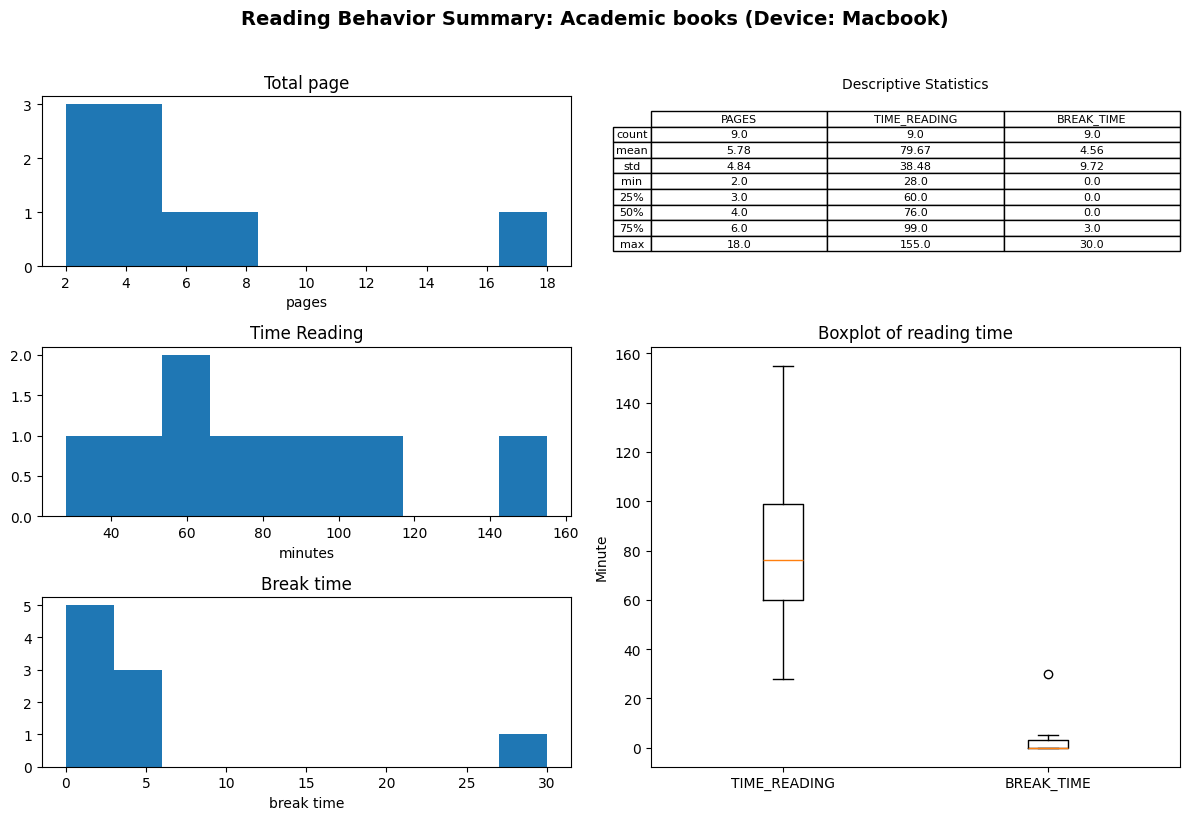

In [5]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['PAGES', 'TIME_READING', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['PAGES'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['TIME_READING'])
ax2.set_xlabel("minutes")
ax2.set_title("Time Reading")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['TIME_READING'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['TIME_READING', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

fig.suptitle("Reading Behavior Summary: Academic books (Device: Macbook)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Get means of both columns
means = ps[['PAGES', 'TIME_READING']].mean()
print(means[0], means[1])

5.777777777777778 79.66666666666667


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_63804/2580457362.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(means[0], means[1])


In [7]:
def total_day(totalPages, hoursSpentPerDay):
    return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay

In [8]:
print(total_day(totalPages=121, hoursSpentPerDay=5))

5.561346153846155


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_63804/966302175.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay


# Model

## Logistic regression classification

Just provide the book's difficulty level and the number of minutes you plan to read; the model will predict how many pages you will finish (good means finishing more than 5 pages/hour, bad means less than 5 pages/hour)

In [9]:
query = """
SELECT timestampdiff(MINUTE, ACTLOG_START, AO_FINISH) as TIME_READING,
    BREAK_TIME,
    CASE
        WHEN FOCUS_LEVEL IN ('very_low', 'low') THEN 1
        WHEN FOCUS_LEVEL = 'medium' THEN 2
        WHEN FOCUS_LEVEL IN ('high', 'very_high') THEN 3
        ELSE NULL
    END AS FOCUS_LEVEL,
    TOTAL_COUNT as PAGES,
    CASE
        WHEN CONTENT_LEVEL IN ('very_easy', 'easy') THEN 1
        WHEN CONTENT_LEVEL = 'moderate' THEN 2
        WHEN CONTENT_LEVEL IN ('hard', 'very_hard') THEN 3
        ELSE NULL
    END AS CONTENT_LEVEL_ENUM,
    CASE 
        WHEN (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 > 5 THEN 'good'
        WHEN (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 < 5 THEN 'bad'
        ELSE NULL
    END AS PAGES_PER_HOUR_RATING
FROM ACTIVITY
    natural join ACTIVITY_LOG
    natural join ACTIVITY_OUTPUT
    natural join KIT_COUNT
    natural join KIT_READING
where (TRANSLATION is not null)
    and (ACTIVITY_ID=12)
    and (unit_count like 'pages');
        """
ps = pd.read_sql(query, engine)
ps.head()

,TIME_READING,BREAK_TIME,FOCUS_LEVEL,PAGES,CONTENT_LEVEL_ENUM,PAGES_PER_HOUR_RATING
0,45,3,2,4.0,3,good
1,76,0,3,3.0,3,bad
2,60,0,3,4.0,3,bad
3,79,0,3,7.0,3,good
4,99,0,3,6.0,3,bad


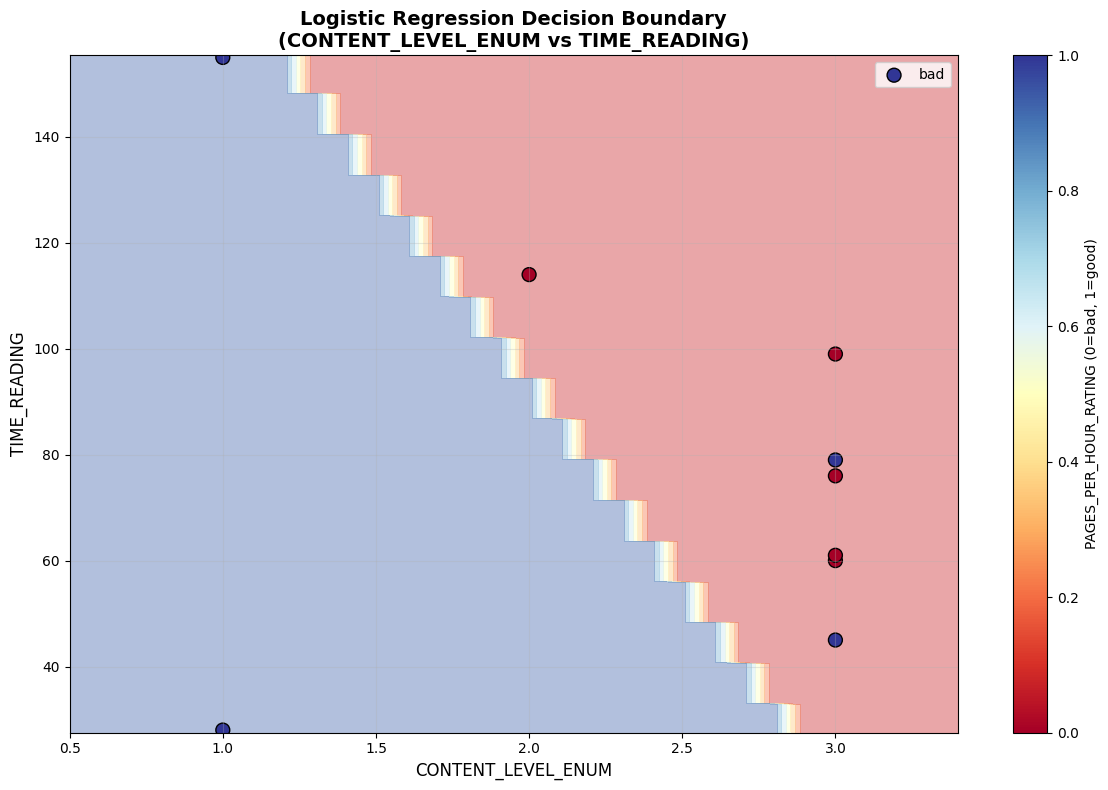

Model Accuracy: 0.7778
Model Coefficients: [[-0.82151183 -0.01070041]]
Model Intercept: [2.65296125]


In [10]:
# Logistic Regression với Decision Boundary
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Chuẩn bị dữ liệu
# Loại bỏ các dòng có giá trị NULL
ps_clean = ps.dropna(subset=['CONTENT_LEVEL_ENUM', 'TIME_READING', 'PAGES_PER_HOUR_RATING'])

# Tạo features (X) và target (y)
X = ps_clean[['CONTENT_LEVEL_ENUM', 'TIME_READING']].values
y = ps_clean['PAGES_PER_HOUR_RATING'].values

# Encode target variable (good=1, bad=0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X, y_encoded)

# Tạo meshgrid để vẽ decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Dự đoán trên meshgrid
Z = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vẽ decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_encoded, cmap='RdYlBu', edgecolors='black', s=100)
plt.colorbar(scatter, label='PAGES_PER_HOUR_RATING (0=bad, 1=good)')
plt.xlabel('CONTENT_LEVEL_ENUM', fontsize=12)
plt.ylabel('TIME_READING', fontsize=12)
plt.title('Logistic Regression Decision Boundary\n(CONTENT_LEVEL_ENUM vs TIME_READING)', fontsize=14, fontweight='bold')
plt.legend(['bad', 'good'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In thông tin model
print(f"Model Accuracy: {lr_model.score(X, y_encoded):.4f}")
print(f"Model Coefficients: {lr_model.coef_}")
print(f"Model Intercept: {lr_model.intercept_}")

In [11]:
# Function để dự đoán PAGES_PER_HOUR_RATING
def predict_rating(content_level_enum, time_reading):
    """
    Dự đoán PAGES_PER_HOUR_RATING dựa trên CONTENT_LEVEL_ENUM và TIME_READING
    
    Parameters:
    -----------
    content_level_enum : int
        Mức độ khó của nội dung (1=easy, 2=moderate, 3=hard)
    time_reading : float
        Thời gian đọc (phút)
    
    Returns:
    --------
    dict : Dictionary chứa prediction và probability
        - prediction: 'good' hoặc 'bad'
        - probability: Xác suất của prediction
        - probability_good: Xác suất rating là 'good'
        - probability_bad: Xác suất rating là 'bad'
        - content_level_enum: Giá trị input
        - time_reading: Giá trị input
    """
    # Kiểm tra input
    if content_level_enum not in [1, 2, 3]:
        raise ValueError("CONTENT_LEVEL_ENUM phải là 1, 2, hoặc 3")
    if time_reading < 0:
        raise ValueError("TIME_READING phải là số dương")
    
    # Tạo input array
    X_input = np.array([[content_level_enum, time_reading]])
    
    # Dự đoán
    prediction_encoded = lr_model.predict(X_input)[0]
    probabilities = lr_model.predict_proba(X_input)[0]
    
    # Decode prediction
    prediction_label = le.inverse_transform([prediction_encoded])[0]
    
    # Lấy probability cho mỗi class
    prob_bad = probabilities[0]
    prob_good = probabilities[1]
    
    return {
        'prediction': prediction_label,
        'probability': float(prob_good if prediction_encoded == 1 else prob_bad),
        'probability_good': float(prob_good),
        'probability_bad': float(prob_bad),
        'content_level_enum': content_level_enum,
        'time_reading': time_reading
    }

In [12]:
tests = [
    (3, 60),
    (2, 60),
]

In [13]:
for content_level, time_reading in tests:
    result = predict_rating(content_level, time_reading)
    print(f"Độ khó tài liệu: {result['content_level_enum']}, Thời gian đọc: {result['time_reading']} phút")
    print(f"Dự đoán: {result['prediction']}")
    print(f"Xác suất good là: {result['probability_good']:.4f}")
    print(f"Xác suất bad là: {result['probability_bad']:.4f}\n")

Độ khó tài liệu: 3, Thời gian đọc: 60 phút
Dự đoán: bad
Xác suất good là: 0.3885
Xác suất bad là: 0.6115

Độ khó tài liệu: 2, Thời gian đọc: 60 phút
Dự đoán: good
Xác suất good là: 0.5910
Xác suất bad là: 0.4090

